## Parte 1 – Modello baseline

In [11]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

4422102/4422102 [==============================] - 1s 0us/step
Epoch 1/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.7275 - accuracy: 0.7565 - val_loss: 0.5535 - val_accuracy: 0.8030
Epoch 2/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4911 - accuracy: 0.8286 - val_loss: 0.4518 - val_accuracy: 0.8466
Epoch 3/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4434 - accuracy: 0.8439 - val_loss: 0.4342 - val_accuracy: 0.8502
Epoch 4/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4138 - accuracy: 0.8542 - val_loss: 0.4031 - val_accuracy: 0.8608
Epoch 5/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3951 - accuracy: 0.8608 - val_loss: 0.3917 - val_accuracy: 0.8628
Epoch 6/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3776 - accuracy: 0.8672 - val_loss: 0.3886 - val_accuracy: 0.8634
Epoch 7/20
1719/1719 [==============================] - 3s 2ms/step - los

1. **Dopo quante epoche il modello inizia eventualmente a overfittare?**
Il modello inizia a overfittare dopo la diciottesima epoca, che è l'early stopping; infatti, come si può notare, durante il training, la loss diminuisce e l'accuracy aumenta, mentre durante la validation, la loss aumenta e l'accuracy diminuisce.

2. **La validation accuracy segue da vicino la training accuracy oppure no?**
La validation accuracy segue la training accuracy, vale a dire, seguono lo stesso andamento verso l'alto perché ciò che il modello impara durante il training è efficace anche sui dati di validation.  


3. **Le curve sono regolari o mostrano oscillazioni importanti?**
Le curve sono regolari e non mostrano oscillazioni importanti. Di conseguenza, il processo di training è costante.


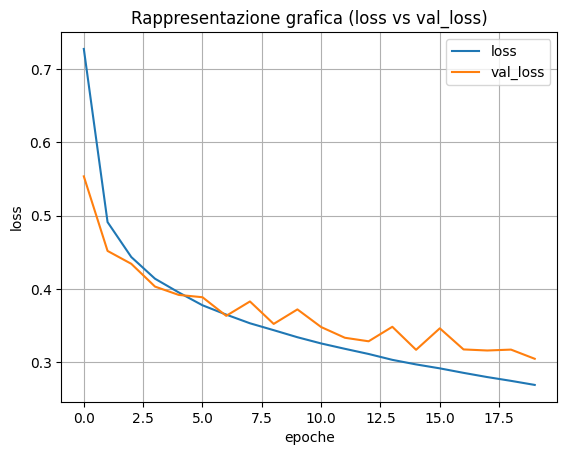

In [12]:
plt.plot(history.history['loss'], label="loss")
plt.plot(history.history['val_loss'], label="val_loss")

plt.title("Rappresentazione grafica (loss vs val_loss)")
plt.xlabel("epoche")
plt.ylabel("loss")
plt.grid()
plt.legend()
plt.show()

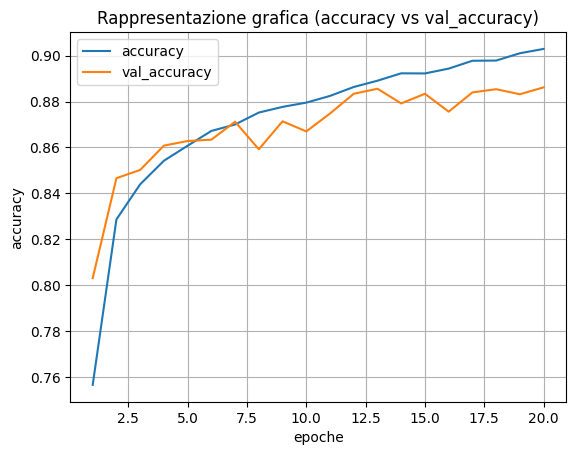

In [13]:

epochs_range = range(1, len(history.history['accuracy'])+1)

plt.plot(epochs_range, history.history['accuracy'], label="accuracy")
plt.plot(epochs_range, history.history['val_accuracy'], label="val_accuracy")

plt.title("Rappresentazione grafica (accuracy vs val_accuracy)")
plt.xlabel('epoche')
plt.ylabel('accuracy')
plt.grid()
plt.legend()
plt.show()

## Parte 2 - Glorot vs He

In [14]:
# modello con inilizzazione glorot_uniform
model_glorot = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu", kernel_initializer="glorot_uniform"),
    keras.layers.Dense(100, activation="relu", kernel_initializer="glorot_uniform"),
    keras.layers.Dense(10, activation="softmax")
])

model_glorot.compile(loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    metrics=["accuracy"])

history_glorot = model_glorot.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))



Epoch 1/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.7256 - accuracy: 0.7658 - val_loss: 0.4998 - val_accuracy: 0.8330
Epoch 2/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4882 - accuracy: 0.8314 - val_loss: 0.4614 - val_accuracy: 0.8414
Epoch 3/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4439 - accuracy: 0.8446 - val_loss: 0.4159 - val_accuracy: 0.8544
Epoch 4/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4182 - accuracy: 0.8537 - val_loss: 0.4011 - val_accuracy: 0.8618
Epoch 5/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3976 - accuracy: 0.8599 - val_loss: 0.3958 - val_accuracy: 0.8610
Epoch 6/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3815 - accuracy: 0.8662 - val_loss: 0.4083 - val_accuracy: 0.8588
Epoch 7/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3673 - accuracy: 0.8711 - val_loss: 0.3788 - val_accuracy:

In [15]:
# modello con inilizzazione he_normal
model_he = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

model_he.compile(loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    metrics=["accuracy"])

history_he = model_he.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.7067 - accuracy: 0.7635 - val_loss: 0.5020 - val_accuracy: 0.8282
Epoch 2/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4848 - accuracy: 0.8308 - val_loss: 0.4474 - val_accuracy: 0.8492
Epoch 3/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4408 - accuracy: 0.8458 - val_loss: 0.4145 - val_accuracy: 0.8594
Epoch 4/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4139 - accuracy: 0.8555 - val_loss: 0.3998 - val_accuracy: 0.8620
Epoch 5/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3943 - accuracy: 0.8607 - val_loss: 0.3786 - val_accuracy: 0.8686
Epoch 6/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3783 - accuracy: 0.8669 - val_loss: 0.3726 - val_accuracy: 0.8720
Epoch 7/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3643 - accuracy: 0.8715 - val_loss: 0.3811 - val_accuracy:

1. **Quale inizializzazione sembra favorire una discesa più rapida della loss nelle prime epoche?**
L'inizializzazione che favorisce la discesa più rapida della loss nelle prime epoche è la **He** perché come si nota dal grafico, grazie a He, il modello parte con un errore più basso.

2. **Le differenze si osservano solo all'inizio o anche nelle metriche finali?**
La differenza si osserva anche nelle metriche finali, è sempre l'inizializzazione **He** ad essere più rapida per tutto il training.

3. **Perché He è in genere una scelta naturale con ReLU e varianti di ReLU?**
Perché He riduce gradienti instabili affinché i modelli più profondi siano ottimizzati, rende la fase di training meno sensibile durante l'inizializzazione e l'apprendimento risulta più rapido. Ha anche un effetto di regolarizzazione.

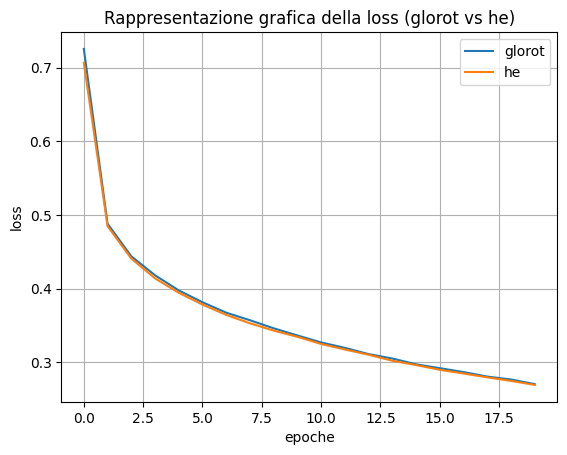

In [16]:
plt.plot(history_glorot.history['loss'], label="glorot")
plt.plot(history_he.history['loss'], label="he")

plt.title("Rappresentazione grafica della loss (glorot vs he)")
plt.xlabel("epoche")
plt.ylabel("loss")
plt.grid()
plt.legend()
plt.show()

In [17]:
print(f"Glorot - val_accuracy finale: {history_glorot.history['val_accuracy'][-1]:.4f}")
print(f"Glorot - val_loss finale: {history_glorot.history['val_loss'][-1]:.4f}")

print(f"He - val_accuracy finale: {history_he.history['val_accuracy'][-1]:.4f}")
print(f"He - val_loss finale: {history_he.history['val_loss'][-1]:.4f}")

Glorot - val_accuracy finale: 0.8888
Glorot - val_loss finale: 0.3081
He - val_accuracy finale: 0.8864
He - val_loss finale: 0.3096


## Parte 3 - ReLU, Leaky ReLU ed ELU

In questa sezione confrontiamo tre funzioni di attivazione molto usate nelle reti neurali profonde:
- **ReLU**: azzerà completamente i neuroni con input negativo → rischio *dying ReLU*
- **Leaky ReLU**: lascia passare un piccolo gradiente ($\alpha$=0.01) anche per input negativi
- **ELU**: curva smooth con valori negativi, media delle attivazioni più vicina a zero

Tutti i modelli usano inizializzazione **He**, coerente con attivazioni della famiglia ReLU.

### Import

In [18]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

### Modello con ReLU

In [19]:
model_relu = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

### Modello con Leaky ReLU

In [20]:
model_lrelu = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dense(10, activation="softmax")
])

### Modello con ELU

In [21]:
model_elu = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

### Training dei tre modelli

Tutti e tre i modelli vengono addestrati con:
- Ottimizzatore: **SGD**
- Loss: `sparse_categorical_crossentropy`
- Epoche: 20, Batch size: 32
- Stesso validation set

In questo modo le differenze nelle curve dipendono **solo dall'attivazione**.

### Training ReLU

In [22]:
model_relu.compile(optimizer="adam",
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])

history_relu = model_relu.fit(X_train, y_train, epochs=20, batch_size=32,
                               validation_data=(X_valid, y_valid))

Epoch 1/20
1719/1719 [==============================] - 9s 5ms/step - loss: 0.4807 - accuracy: 0.8268 - val_loss: 0.3727 - val_accuracy: 0.8704
Epoch 2/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3674 - accuracy: 0.8646 - val_loss: 0.3325 - val_accuracy: 0.8768
Epoch 3/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3303 - accuracy: 0.8787 - val_loss: 0.3339 - val_accuracy: 0.8770
Epoch 4/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3057 - accuracy: 0.8870 - val_loss: 0.3469 - val_accuracy: 0.8780
Epoch 5/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2884 - accuracy: 0.8927 - val_loss: 0.3218 - val_accuracy: 0.8806
Epoch 6/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2729 - accuracy: 0.8997 - val_loss: 0.3043 - val_accuracy: 0.8908
Epoch 7/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2612 - accuracy: 0.9013 - val_loss: 0.3067 - val_accuracy:

### Training Leaky ReLU

In [23]:
model_lrelu.compile(optimizer="adam",
                    loss="sparse_categorical_crossentropy",
                    metrics=["accuracy"])

history_lrelu = model_lrelu.fit(X_train, y_train, epochs=20, batch_size=32,
                                 validation_data=(X_valid, y_valid))

Epoch 1/20
1719/1719 [==============================] - 9s 5ms/step - loss: 0.4852 - accuracy: 0.8253 - val_loss: 0.4019 - val_accuracy: 0.8530
Epoch 2/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3629 - accuracy: 0.8672 - val_loss: 0.3994 - val_accuracy: 0.8538
Epoch 3/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3293 - accuracy: 0.8778 - val_loss: 0.3139 - val_accuracy: 0.8846
Epoch 4/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3052 - accuracy: 0.8865 - val_loss: 0.3240 - val_accuracy: 0.8846
Epoch 5/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2860 - accuracy: 0.8930 - val_loss: 0.3114 - val_accuracy: 0.8888
Epoch 6/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2716 - accuracy: 0.8973 - val_loss: 0.3160 - val_accuracy: 0.8914
Epoch 7/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2594 - accuracy: 0.9022 - val_loss: 0.3190 - val_accuracy:

### Training ELU

In [24]:
model_elu.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

history_elu = model_elu.fit(X_train, y_train, epochs=20, batch_size=32,
                             validation_data=(X_valid, y_valid))

Epoch 1/20
1719/1719 [==============================] - 9s 5ms/step - loss: 0.4827 - accuracy: 0.8245 - val_loss: 0.4111 - val_accuracy: 0.8510
Epoch 2/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3692 - accuracy: 0.8645 - val_loss: 0.3587 - val_accuracy: 0.8706
Epoch 3/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3343 - accuracy: 0.8752 - val_loss: 0.3796 - val_accuracy: 0.8588
Epoch 4/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3071 - accuracy: 0.8845 - val_loss: 0.3279 - val_accuracy: 0.8772
Epoch 5/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2869 - accuracy: 0.8925 - val_loss: 0.3201 - val_accuracy: 0.8828
Epoch 6/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2754 - accuracy: 0.8957 - val_loss: 0.3425 - val_accuracy: 0.8800
Epoch 7/20
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2584 - accuracy: 0.9018 - val_loss: 0.3265 - val_accuracy:

### Confrontro validation accuracy

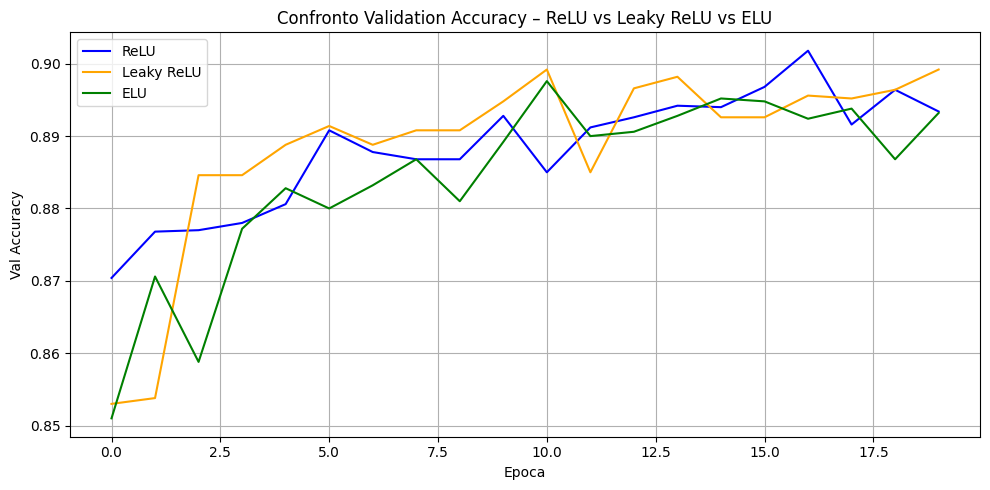

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(history_relu.history["val_accuracy"],  label="ReLU",       color="blue")
plt.plot(history_lrelu.history["val_accuracy"], label="Leaky ReLU", color="orange")
plt.plot(history_elu.history["val_accuracy"],   label="ELU",        color="green")
plt.title("Confronto Validation Accuracy – ReLU vs Leaky ReLU vs ELU")
plt.xlabel("Epoca")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Stampa valori

In [26]:
for name, history in [("ReLU", history_relu), ("Leaky ReLU", history_lrelu), ("ELU", history_elu)]:
    final = history.history["val_accuracy"][-1]
    best  = max(history.history["val_accuracy"])
    print(f"{name:12s} val_accuracy finale: {final:.4f} | massima: {best:.4f}")

for name, history in [("ReLU", history_relu), ("Leaky ReLU", history_lrelu), ("ELU", history_elu)]:
    print(f"{name:12s} val_loss finale: {history.history['val_loss'][-1]:.4f}")

ReLU         val_accuracy finale: 0.8934 | massima: 0.9018
Leaky ReLU   val_accuracy finale: 0.8992 | massima: 0.8992
ELU          val_accuracy finale: 0.8932 | massima: 0.8976
ReLU         val_loss finale: 0.3449
Leaky ReLU   val_loss finale: 0.3412
ELU          val_loss finale: 0.3772


### Domande

- **Quale attivazione porta alla validation accuracy migliore?**
    Basandoci sul grafico, tutte e tre le reti convergono verso valori finali di accuracy simili. Tuttavia, la ReLU tocca il picco massimo assoluto di validation accuracy intorno all'epoca 13, superando la soglia dello 0.90. L'ELU raggiunge valori massimi simili verso l'epoca 15. La Leaky ReLU, anche se non raggiunge i picchi estremi della ReLU, termina l'addestramento mantenendosi su una media alta e constante.

- **Quale attivazione sembra più stabile nelle prime epoche?**
    L'ELU e la Leaky ReLU si dimostrano le più stabili nelle prime fasi. L'ELU parte già dal valore di accuracy più alto nell'epoca 0 e mostra una crescita regolare. Questo è dato dalla sua capacità di mantenere attivazioni medie vicine allo zero e ridurre il rischio di scomparsa dei gradienti. La Leaky ReLU invece, pur partendo dal punto più basso, mostra un incremento rapido e costante nelle prime epoche. Al contrario, la ReLU standard è più instabile, registrando forti oscillazioni iniziali.

- **Il modello con Leaky ReLU mostra vantaggi rispetto a ReLU standard?**
    Sì, il vantaggio principale è la stabilità. La curva della Leaky ReLU varia meno rispetto a quella della ReLU standard, evitando le forti oscillazioni e i cali improvvisi. Questo perchè mantenendo una piccola pendenza per gli input negativi , impedisce il dying ReLU problem e permette loro di continuare ad aggiornarsi ricevendo gradienti in modo continuo.

- **In quali casi ELU sembra comportarsi meglio o peggio delle altre varianti?**
    Si comporta meglio nelle prime fasi del training, garantendo un'ottima accuracy di partenza e un avvio stabile, confermando la sua utilità contro il vanishing gradient. Invece, si comporta peggio tra le epoche 5 e 10 dove mostra delle irregolarità rispetto all'andamento molto più lineare della Leaky ReLU. Inoltre, a livello implementativo, la presenza della componente esponenziale la rende solitamente più costosa da calcolare rispetto alla semplice ReLU, il che potrebbe tradursi in tempi di addestramento più lunghi per singola epoca.

### PARTE 4 - MOMENTUM
Il modello scelto è quello con **ELU + He**, che ha ottenuto la val_accuracy finale migliore nella Parte 3 (0.8970).

Lo addestriamo in due configurazioni con SGD:
- **SGD plain**: momentum=0.0 → aggiornamento classico, solo gradiente corrente;
- **SGD con momentum**: momentum=0.9 → media mobile degli aggiornamenti passati, che accumula velocità nelle direzioni persistenti e smorza le oscillazioni.

La differenza tra i due permette di osservare l'effetto del momentum sulla convergenza e sulla stabilità delle curve.

In [27]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Caricamento e normalizzazione del dataset
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0

# Split train / validation
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

#### Definizione dei modelli

In [28]:
# Modello ELU con SGD plain (momentum=0.0)
model_elu_plain = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

# Modello ELU con SGD momentum (momentum=0.9)
model_elu_momentum = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

#### Definizione degli ottimizzatori

In [29]:
optimizer_plain = keras.optimizers.SGD(learning_rate=0.01, momentum=0.0)
optimizer_momentum = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

#### Training SDG plain

In [30]:
model_elu_plain.compile(optimizer=optimizer_plain,
                        loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])

history_plain = model_elu_plain.fit(X_train, y_train, epochs=20, batch_size=32,
                                     validation_data=(X_valid, y_valid))

Epoch 1/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.6338 - accuracy: 0.7856 - val_loss: 0.4969 - val_accuracy: 0.8324
Epoch 2/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4725 - accuracy: 0.8335 - val_loss: 0.4462 - val_accuracy: 0.8454
Epoch 3/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4372 - accuracy: 0.8458 - val_loss: 0.4251 - val_accuracy: 0.8558
Epoch 4/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4160 - accuracy: 0.8519 - val_loss: 0.4364 - val_accuracy: 0.8396
Epoch 5/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4001 - accuracy: 0.8582 - val_loss: 0.3842 - val_accuracy: 0.8656
Epoch 6/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3879 - accuracy: 0.8616 - val_loss: 0.3846 - val_accuracy: 0.8654
Epoch 7/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3763 - accuracy: 0.8660 - val_loss: 0.3840 - val_accuracy:

#### Training SGD con momentum

In [31]:
model_elu_momentum.compile(optimizer=optimizer_momentum,
                            loss="sparse_categorical_crossentropy",
                            metrics=["accuracy"])

history_momentum = model_elu_momentum.fit(X_train, y_train, epochs=20, batch_size=32,
                                           validation_data=(X_valid, y_valid))

Epoch 1/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4991 - accuracy: 0.8183 - val_loss: 0.4088 - val_accuracy: 0.8448
Epoch 2/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3888 - accuracy: 0.8577 - val_loss: 0.4079 - val_accuracy: 0.8508
Epoch 3/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3523 - accuracy: 0.8705 - val_loss: 0.3425 - val_accuracy: 0.8786
Epoch 4/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3287 - accuracy: 0.8792 - val_loss: 0.3346 - val_accuracy: 0.8780
Epoch 5/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3124 - accuracy: 0.8845 - val_loss: 0.3183 - val_accuracy: 0.8836
Epoch 6/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2996 - accuracy: 0.8871 - val_loss: 0.3101 - val_accuracy: 0.8852
Epoch 7/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2851 - accuracy: 0.8940 - val_loss: 0.3119 - val_accuracy:

In [32]:
# modello leaky relu per la tabella
import tensorflow as tf
from tensorflow import keras

model_lrelu_momentum = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dense(10, activation="softmax")
])
optimizer_momentum = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model_lrelu_momentum.compile(optimizer=optimizer_momentum,loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_momentum = model_lrelu_momentum.fit(X_train, y_train, epochs=20, batch_size=32,
                                            validation_data=(X_valid, y_valid))
                    
print(f"val_accuracy finale: {history_momentum.history['val_accuracy'][-1]:.4f}")
print(f"val_loss finale: {history_momentum.history['val_loss'][-1]:.4f}")


Epoch 1/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5171 - accuracy: 0.8157 - val_loss: 0.4016 - val_accuracy: 0.8582
Epoch 2/20
1719/1719 [==============================] - 4s 3ms/step - loss: 0.3844 - accuracy: 0.8600 - val_loss: 0.4176 - val_accuracy: 0.8470
Epoch 3/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3440 - accuracy: 0.8729 - val_loss: 0.3523 - val_accuracy: 0.8702
Epoch 4/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3209 - accuracy: 0.8813 - val_loss: 0.3460 - val_accuracy: 0.8744
Epoch 5/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3049 - accuracy: 0.8871 - val_loss: 0.3179 - val_accuracy: 0.8840
Epoch 6/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2881 - accuracy: 0.8915 - val_loss: 0.3145 - val_accuracy: 0.8834
Epoch 7/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2734 - accuracy: 0.8972 - val_loss: 0.3076 - val_accuracy:

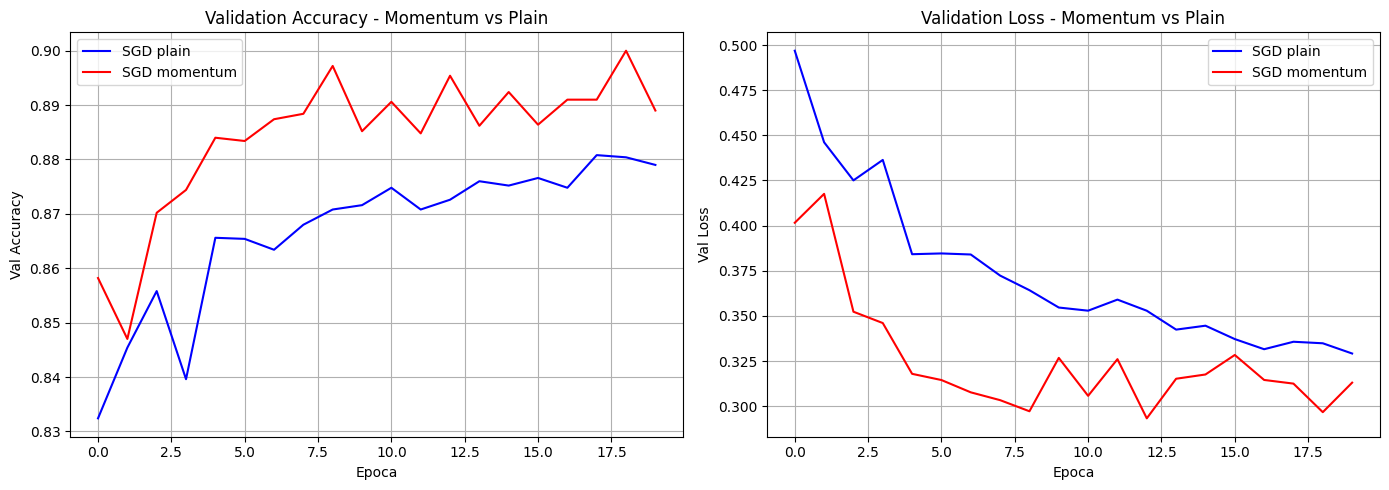

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val Accuracy
axes[0].plot(history_plain.history["val_accuracy"],    label="SGD plain", color="blue")
axes[0].plot(history_momentum.history["val_accuracy"], label="SGD momentum", color="red")
axes[0].set_title("Validation Accuracy - Momentum vs Plain")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Val Accuracy")
axes[0].legend()
axes[0].grid(True)

# Val Loss
axes[1].plot(history_plain.history["val_loss"], label="SGD plain", color="blue")
axes[1].plot(history_momentum.history["val_loss"], label="SGD momentum", color="red")
axes[1].set_title("Validation Loss - Momentum vs Plain")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Val Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [34]:
for name, history in [("SGD plain", history_plain), ("SGD momentum", history_momentum)]:
    final = history.history["val_accuracy"][-1]
    best  = max(history.history["val_accuracy"])
    print(f"{name:15s} val_accuracy finale: {final:.4f} | massima: {best:.4f}")
    

for name, history in [("SGD plain", history_plain), ("SGD momentum", history_momentum)]:
    print(f"{name:15s} → val_loss finale: {history.history['val_loss'][-1]:.4f}")

SGD plain       val_accuracy finale: 0.8790 | massima: 0.8808
SGD momentum    val_accuracy finale: 0.8890 | massima: 0.9000
SGD plain       → val_loss finale: 0.3292
SGD momentum    → val_loss finale: 0.3130


### DOMANDE
- **Il momentum accelera la convergenza?**
    Sì, la curva rossa, che è il momentum a 0.9, parte già da 0.87 dalla prima epoca. Rimane costantemente sopra SGD plain per tutte le 20 epoche. SGD plain raggiunge valori simili solo intorno all'epoca 17-18, con un ritardo di circa 10 epoche.

- **Le oscillazioni della loss diminuiscono o aumentano?**
    La val_loss con momentum scende più rapidamente e si stabilizza intorno a 0.30-0.31, con un'unica oscillazione visibile attorno all'epoca 13. SGD plain invece decresce in modo più lento e regolare ma non raggiunge valori altrettanto bassi (si ferma intorno a 0.33). Il momentum quindi non aumenta le oscillazioni in modo problematico, ma accumula velocità nelle direzioni persistenti del gradiente.

- **Validation accuracy maggiore a parità di epoche?**
    Sì. A 20 epoche SGD momentum raggiunge 0.8938 di SDG plain, un vantaggio di circa 0.011. Il picco massimo di momentum (0.8949) è superiore al massimo di plain (0.8828)

- **Interpretazione fisica del momentum:**
    Il momentum=0.9 agisce come una media mobile esponenziale degli aggiornamenti precedenti: il modello accumula "inerzia" nelle direzioni dove il gradiente è persistente, superando più facilmente plateau e minimi locali piatti. È analogo a una palla che rotola su una superficie: accumula velocità nei tratti in discesa e non si ferma alle piccole irregolarità del terreno. Questo spiega perché nelle prime epoche il momentum converge molto più rapidamente, mentre SGD plain aggiorna i pesi solo in base al gradiente istantaneo.

### PARTE 5 - Dropout

In [35]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0

X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

Il modello scelto è **ELU + He + SGD momentum=0.9**, il migliore delle parti precedenti.

Il dropout è una tecnica di regolarizzazione che, durante il training, disattiva 
casualmente una frazione dei neuroni a ogni batch. Questo forza la rete a non 
dipendere da nessun neurone specifico, riducendo l'overfitting.

Testiamo due valori del tasso di dropout:
- **Dropout 0.3**: spegne il 30% dei neuroni a ogni step
- **Dropout 0.5**: spegne il 50% dei neuroni a ogni step

Il confronto ci permette di valutare quale tasso bilancia meglio 
regolarizzazione e capacità del modello.

#### Definizio dei tre modelli

In [36]:
# Modello senza dropout
model_no_dropout = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dense(10, activation="softmax")
])

# Modello con Dropout 0.3
model_dropout_03 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax")
])

# Modello con Dropout 0.5
model_dropout_05 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])

In [37]:
# modello leaky relu per la tabella
model_lrelu_dropout = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax")
])

model_lrelu_dropout.compile(loss='sparse_categorical_crossentropy',
                            optimizer=optimizer_momentum),
                            metrics=['accuracy'])

history_momentum = model_lrelu_momentum.fit(X_train, y_train, epochs=20, batch_size=32,
                                           validation_data=(X_valid, y_valid))

print(f"val_accuracy finale: {history_momentum.history['val_accuracy'][-1]:.4f}")
print(f"val_loss finale: {history_momentum.history['val_loss'][-1]:.4f}")



IndentationError: unexpected indent (2802032964.py, line 15)

#### Training modello senza dropout

In [26]:
model_no_dropout.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_no_dropout = model_no_dropout.fit(
    X_train, y_train, epochs=20, batch_size=32,
    validation_data=(X_valid, y_valid)
)

Epoch 1/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.5042 - accuracy: 0.8175 - val_loss: 0.4119 - val_accuracy: 0.8556
Epoch 2/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3871 - accuracy: 0.8582 - val_loss: 0.3833 - val_accuracy: 0.8620
Epoch 3/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3531 - accuracy: 0.8695 - val_loss: 0.3885 - val_accuracy: 0.8626
Epoch 4/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3282 - accuracy: 0.8790 - val_loss: 0.3120 - val_accuracy: 0.8858
Epoch 5/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3143 - accuracy: 0.8829 - val_loss: 0.3182 - val_accuracy: 0.8814
Epoch 6/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2991 - accuracy: 0.8882 - val_loss: 0.3016 - val_accuracy: 0.8888
Epoch 7/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2837 - accuracy: 0.8945 - val_loss: 0.3330 - val_accuracy:

#### Training dorpout 0.3

In [27]:
model_dropout_03.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_dropout_03 = model_dropout_03.fit(
    X_train, y_train, epochs=20, batch_size=32,
    validation_data=(X_valid, y_valid)
)

Epoch 1/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.5944 - accuracy: 0.7859 - val_loss: 0.4674 - val_accuracy: 0.8288
Epoch 2/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4768 - accuracy: 0.8273 - val_loss: 0.3957 - val_accuracy: 0.8574
Epoch 3/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4467 - accuracy: 0.8375 - val_loss: 0.3789 - val_accuracy: 0.8664
Epoch 4/20
1719/1719 [==============================] - 4s 3ms/step - loss: 0.4228 - accuracy: 0.8454 - val_loss: 0.3673 - val_accuracy: 0.8684
Epoch 5/20
1719/1719 [==============================] - 4s 3ms/step - loss: 0.4126 - accuracy: 0.8481 - val_loss: 0.3577 - val_accuracy: 0.8656
Epoch 6/20
1719/1719 [==============================] - 4s 3ms/step - loss: 0.4038 - accuracy: 0.8513 - val_loss: 0.3955 - val_accuracy: 0.8602
Epoch 7/20
1719/1719 [==============================] - 4s 3ms/step - loss: 0.3896 - accuracy: 0.8580 - val_loss: 0.3616 - val_accuracy:

#### Training dropout 0.5

In [28]:
model_dropout_05.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_dropout_05 = model_dropout_05.fit(
    X_train, y_train, epochs=20, batch_size=32,
    validation_data=(X_valid, y_valid)
)

Epoch 1/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.7021 - accuracy: 0.7483 - val_loss: 0.4835 - val_accuracy: 0.8266
Epoch 2/20
1719/1719 [==============================] - 4s 3ms/step - loss: 0.5599 - accuracy: 0.8006 - val_loss: 0.4135 - val_accuracy: 0.8568
Epoch 3/20
1719/1719 [==============================] - 4s 3ms/step - loss: 0.5297 - accuracy: 0.8113 - val_loss: 0.4069 - val_accuracy: 0.8562
Epoch 4/20
1719/1719 [==============================] - 4s 3ms/step - loss: 0.5098 - accuracy: 0.8202 - val_loss: 0.3963 - val_accuracy: 0.8526
Epoch 5/20
1719/1719 [==============================] - 4s 3ms/step - loss: 0.4959 - accuracy: 0.8219 - val_loss: 0.3856 - val_accuracy: 0.8606
Epoch 6/20
1719/1719 [==============================] - 4s 3ms/step - loss: 0.4885 - accuracy: 0.8257 - val_loss: 0.4171 - val_accuracy: 0.8472
Epoch 7/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4772 - accuracy: 0.8286 - val_loss: 0.3859 - val_accuracy:

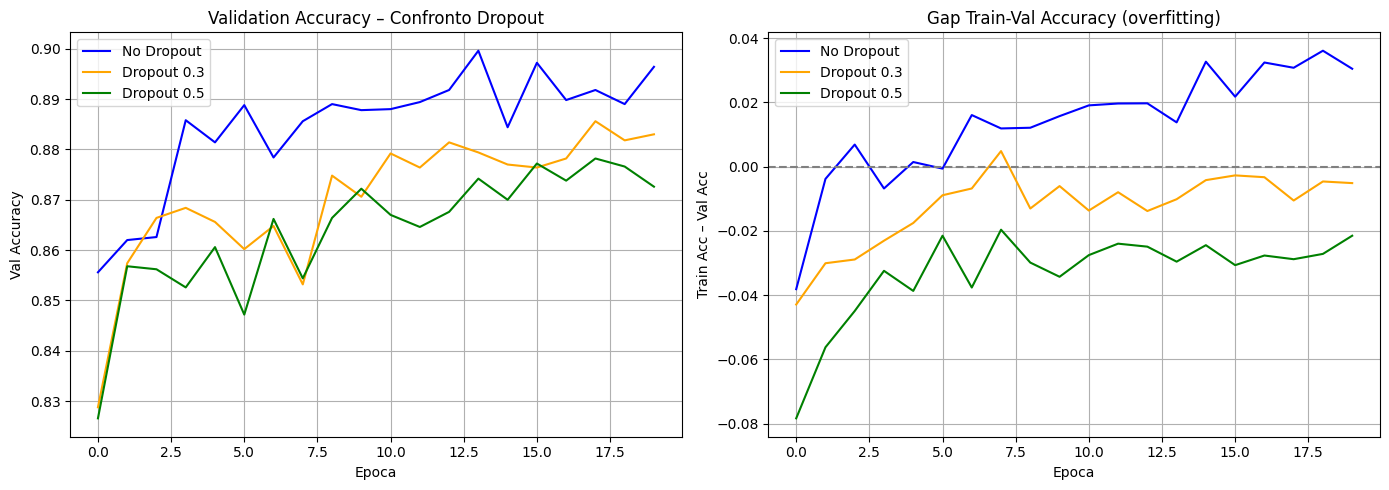

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation accuracy a confronto
axes[0].plot(history_no_dropout.history["val_accuracy"],  label="No Dropout",   color="blue")
axes[0].plot(history_dropout_03.history["val_accuracy"],  label="Dropout 0.3",  color="orange")
axes[0].plot(history_dropout_05.history["val_accuracy"],  label="Dropout 0.5",  color="green")
axes[0].set_title("Validation Accuracy – Confronto Dropout")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Val Accuracy")
axes[0].legend()
axes[0].grid(True)

# Distanza train vs val accuracy (indicatore overfitting)
axes[1].plot(
    [t - v for t, v in zip(history_no_dropout.history["accuracy"],
                            history_no_dropout.history["val_accuracy"])],
    label="No Dropout", color="blue"
)
axes[1].plot(
    [t - v for t, v in zip(history_dropout_03.history["accuracy"],
                            history_dropout_03.history["val_accuracy"])],
    label="Dropout 0.3", color="orange"
)
axes[1].plot(
    [t - v for t, v in zip(history_dropout_05.history["accuracy"],
                            history_dropout_05.history["val_accuracy"])],
    label="Dropout 0.5", color="green"
)
axes[1].set_title("Gap Train-Val Accuracy (overfitting)")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Train Acc – Val Acc")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [30]:
for name, history in [("No Dropout",  history_no_dropout),
                       ("Dropout 0.3", history_dropout_03),
                       ("Dropout 0.5", history_dropout_05)]:
    val_final  = history.history["val_accuracy"][-1]
    train_final = history.history["accuracy"][-1]
    gap = train_final - val_final
    print(f"{name:13s} train: {train_final:.4f} | val: {val_final:.4f} | gap: {gap:.4f}")

for name, history in [("No Dropout",  history_no_dropout),
                      ("Dropout 0.3", history_dropout_03),
                      ("Dropout 0.5", history_dropout_05)]:
    print(f"{name:13s} val_loss finale: {history.history['val_loss'][-1]:.4f}")


No Dropout    train: 0.9269 | val: 0.8964 | gap: 0.0305
Dropout 0.3   train: 0.8779 | val: 0.8830 | gap: -0.0051
Dropout 0.5   train: 0.8511 | val: 0.8726 | gap: -0.0215
No Dropout    val_loss finale: 0.3065
Dropout 0.3   val_loss finale: 0.3226
Dropout 0.5   val_loss finale: 0.3569


### DOMANDE
- **La training accuracy diminuisce con dropout? Perché questo non è necessariamente un male?**
    Sì, la training accuracy passa da 0.9282 (senza dropout) a 0.8789 (dropout a 0.3) fino a 0.8503 (dropout a 0.5). Non è un male poiché durante il training il dropout disattiva neuroni casualmente, renendo il task artificialmente più difficile e impendendo alla rete di memorizzare i dati. In inferenza tutti i neurosni sono attivi, quindi la val_accuracy non subisce lo stesso calo

- **La validation accuracy migliora rispetto al modello senza dropout?**
    I valori di validation accuracy rimangono simili tra i modelli con dropout e i modelli senza droput, ma generalmente non migliora perchè il modello senza dropout ha un gap di +0.047. Questo significa che senza dropout, la rete stava overfittando.

- **Quale valore di dropout sembra il più efficace sul dataset usato?**
    Il valore più efficace sembra essere Dropout 0.3 perchè mantiene una val_accuracy finale di 0.8804, valore molto simile al modello senza dropout (0.8808). Il valore Dropout 0.5 invece abbassa sia la train_accuracy che la val_accuracy.

- **Il dropout riduce la distanza tra training e validation performance?**
    Si. Dal secondo grafico si può notare che senza il Dropout si ha un gap crescente fino a 0.047, con Dropout 0.3 si ha un gap stabile intorno a 0 mentre con Dropout 0.5 si ha un gap negativo e la val_accuracy supera la train_accuracy.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5700d1a3-48c2-45d9-a672-84b755126fc8' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>